In [1]:
import numpy as np
import random 
import gymnasium as gym

import numpy as np
import pandas as pd
import torch

from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt

In [2]:
# seed random number generators for reproducable results
np.random.seed (0)
random.seed(0)
torch.manual_seed(0)

# SAMPLE DATA

In [3]:
# for details see: https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py
CART_POS="cartPos" # cart position
CART_VEL="cartVel" # cart velocity
PEND_POS="pendPos" # pendulum position
PEND_VEL="pendVel" # pendulum velocity
EPISODE="episode"
STEP="step"
ACTION="action"

STATE = [CART_POS, CART_VEL, PEND_POS, PEND_VEL] 
STATE_WITH_ACTION = [CART_POS, CART_VEL, PEND_POS, PEND_VEL, ACTION]

# generate CartPole transitions    
def sample_data (episodes=10000, seed=0):
    env = gym.make ("CartPole-v1")

    ### CREATE EMPTY Pandas dataset
    transitions = []

    ### SAMPLE DATA
    for episode in range (episodes):
        #print ("Start of episode %d" % episode)
        obs, _info = env.reset(seed=episode)  # seed with episode ID for reproducing results
        step = 0
        done = False

        while step < 500 and not done:
            step += 1
            action = env.action_space.sample() # creates N random episodes by taking random actions

            # records state, action, episode ID for each step
            transitions.append({CART_POS:obs[0], CART_VEL:obs[1], 
                             PEND_POS:obs[2], PEND_VEL:obs[3],
                             EPISODE:episode, STEP:step, ACTION:action})

            obs, reward, terminated, truncated, info = env.step(action) # executes one step of the CartPole environment
            done = terminated or truncated # stop at step 500 or when episode ends

        #print ("  --> finished after %d steps" % step)
        
    return pd.DataFrame(transitions) # return DataFrame with all transitions


df = sample_data (episodes=200, seed=0)

In [4]:
df.dtypes

cartPos    float32
cartVel    float32
pendPos    float32
pendVel    float32
episode      int64
step         int64
action       int64
dtype: object

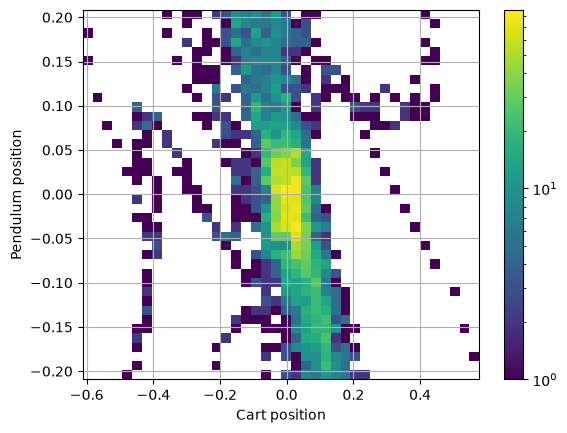

In [5]:
#plt.hist2d(, bins=(50, 50), cmap=plt.cm.Reds)
# showing which states appear most frequently
h = plt.hist2d(df[CART_POS], df[PEND_POS], bins=40, norm=LogNorm())
plt.colorbar(h[3])
plt.grid()
plt.xlabel ("Cart position")
plt.ylabel ("Pendulum position")
plt.show()


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >], dtype=object)

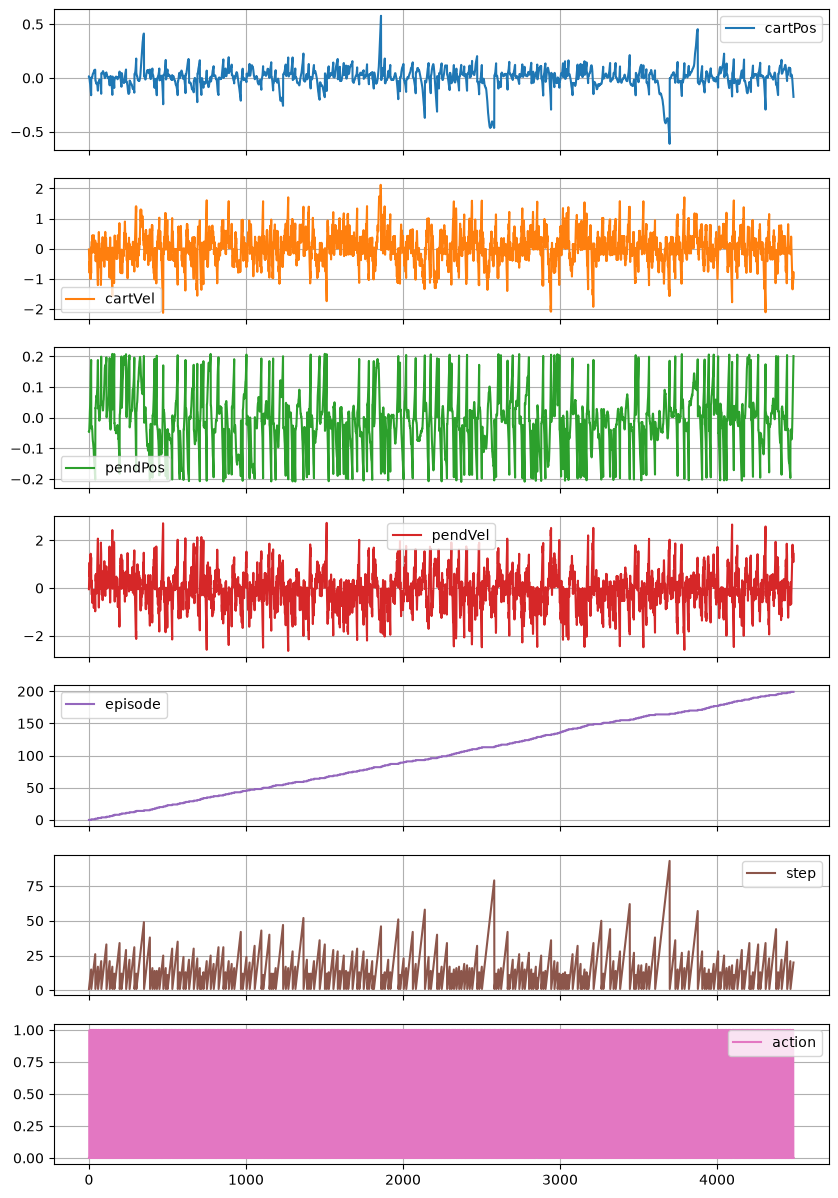

In [6]:
df.plot(subplots=True, figsize=(10,15), grid=True)

# Generate pattern data 

In [7]:
df

,cartPos,cartVel,pendPos,pendVel,episode,step,action
0,0.013696,-0.023021,-0.045903,-0.048347,0,1,0
1,0.013236,-0.217456,-0.046870,0.229507,0,2,0
2,0.008887,-0.411878,-0.042279,0.507045,0,3,0
3,0.000649,-0.606379,-0.032139,0.786110,0,4,0
4,-0.011479,-0.801045,-0.016416,1.068511,0,5,1
...,...,...,...,...,...,...,...
4483,-0.098903,-0.957175,0.095738,1.260520,199,16,0
4484,-0.118046,-1.153382,0.120948,1.581587,199,17,1
4485,-0.141114,-0.959889,0.152580,1.328941,199,18,1
4486,-0.160312,-0.766986,0.179159,1.087632,199,19,0


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from typing import Tuple


def build_xy_from_episode_df(group: pd.DataFrame, lags: int):
    """Build sliding-window (X, Y) pairs from a *single* episode DataFrame.

    X feature vector for each sample is the concatenation of [state + action]
    over `lags` time steps. Target Y is the *next* state (no action) after the
    window.
    """
    X_list, Y_list = [], []
    group = group.sort_values(by=STEP)
    if len(group) <= lags:
        return X_list, Y_list
    for i in range(len(group) - lags):
        window = group.iloc[i:i+lags] # last 4 steps
        next_row = group.iloc[i+lags]
        # Flatten window: (lags * 5) features: cart_pos, cart_vel, pend_pos, pend_vel, action
        feat = []
        for _, row in window.iterrows():
            #feat.extend([
            #    row[CART_POS], row[CART_VEL], row[PEND_POS], row[PEND_VEL], row[ACTION]
            #])
            feat.extend(row[STATE_WITH_ACTION])

        #target = [
        #    next_row[CART_POS], next_row[CART_VEL], next_row[PEND_POS], next_row[PEND_VEL]
        #]
        target = next_row[STATE]

        X_list.append(feat)
        Y_list.append(target)
    return X_list, Y_list


def get_train_val_data(df: pd.DataFrame, lags: int = 4, train_val_split: float = 0.7, random_state: int = 42):
    """Generate train/val tensors plus normalization stats from a transitions DataFrame.

    **Important**: Normalization statistics are computed *from the training split only*
    to avoid data leakage.

    Returns
    -------
    (X_train, Y_train), (X_val, Y_val), (x_mean, x_std), (y_mean, y_std)
    """
    X_all, Y_all = [], []
    for _, group in df.groupby(EPISODE):
        Xg, Yg = build_xy_from_episode_df(group, lags)
        X_all.extend(Xg)
        Y_all.extend(Yg)

    if len(X_all) == 0:
        raise ValueError("No samples produced. Check that your DataFrame has enough steps per episode for the specified lags.")

    import numpy as np
    X_all = torch.tensor(np.asarray(X_all, dtype=float), dtype=torch.float32)
    Y_all = torch.tensor(np.asarray(Y_all, dtype=float), dtype=torch.float32)

    # Split BEFORE computing normalization stats
    X_train, X_val, Y_train, Y_val = train_test_split(
        X_all, Y_all, train_size=train_val_split, random_state=random_state, shuffle=True
    )

    # Compute normalization stats from training split only
    x_mean = X_train.mean(dim=0)
    x_std = X_train.std(dim=0)
    # Avoid div-by-zero: replace zeros with 1.0
    x_std = torch.where(x_std > 0, x_std, torch.ones_like(x_std))

    y_mean = Y_train.mean(dim=0)
    y_std = Y_train.std(dim=0)
    y_std = torch.where(y_std > 0, y_std, torch.ones_like(y_std))

    return (X_train, Y_train), (X_val, Y_val), (x_mean, x_std), (y_mean, y_std)

In [9]:
# ------------------------------------------------------------------
# Dataset wrapping w/ on-the-fly normalization
# ------------------------------------------------------------------
class NormalizedTensorDataset(Dataset):
    def __init__(self, X: torch.Tensor, Y: torch.Tensor, x_mean: torch.Tensor, x_std: torch.Tensor, y_mean: torch.Tensor, y_std: torch.Tensor, normalize_y: bool = True):
        self.X = X
        self.Y = Y
        self.x_mean = x_mean
        self.x_std = x_std
        self.y_mean = y_mean
        self.y_std = y_std
        self.normalize_y = normalize_y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = (self.X[idx] - self.x_mean) / self.x_std # (value - mean) / std
        if self.normalize_y:
            y = (self.Y[idx] - self.y_mean) / self.y_std
        else:
            y = self.Y[idx]
        return x, y

In [10]:
# ------------------------------------------------------------------
# Simple 3-Layer MLP
# ------------------------------------------------------------------
class MLP3(nn.Module):
    """A basic 3-layer perceptron: Input -> hidden1 -> hidden2 -> output.

    hidden_sizes: tuple (h1, h2)
    activation: callable returning nn.Module, e.g., nn.ReLU
    """
    def __init__(self, in_dim: int, out_dim: int, hidden_sizes=(128, 64), activation=nn.ReLU):
        super().__init__()
        h1, h2 = hidden_sizes
        self.net = nn.Sequential(
            nn.Linear(in_dim, h1), # 20 -> 128
            activation(),
            nn.Linear(h1, h2), # 128 -> 64
            activation(),
            nn.Linear(h2, out_dim), # 64 -> 4, 4 state variables
        )

    def forward(self, x):
        return self.net(x)

In [11]:
# ------------------------------------------------------------------
# Training w/ Early Stopping
# ------------------------------------------------------------------

def train_model(model: nn.Module,
                train_loader: DataLoader,
                val_loader: DataLoader,
                optimizer: optim.Optimizer,
                criterion: nn.Module = nn.MSELoss(),
                max_epochs: int = 1000,
                patience: int = 50, 
                device: str = None):
    """Train model w/ early stopping based on validation loss.

    Stops if validation loss does not improve for `patience` *epochs*.

    Returns
    -------
    best_state_dict, history
        best_state_dict: weights at lowest val loss (copy of state_dict)
        history: dict w/ lists: 'train_loss', 'val_loss'
    """
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)

    best_val = float('inf')
    best_state = None
    epochs_no_improve = 0

    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, max_epochs + 1):
        # ---- Train ----
        model.train()
        running_train = 0.0
        n_train = 0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            batch_sz = xb.size(0)
            running_train += loss.item() * batch_sz
            n_train += batch_sz
        train_loss = running_train / max(n_train, 1)

        # ---- Validate ----
        model.eval()
        running_val = 0.0
        n_val = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                batch_sz = xb.size(0)
                running_val += loss.item() * batch_sz
                n_val += batch_sz
        val_loss = running_val / max(n_val, 1)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        # Early stopping check
        if val_loss < best_val - 1e-8:  # small tolerance to count real improvements
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
            print(f"Epoch {epoch}: train {train_loss:.6f}  val {val_loss:.6f} => val loss improved!")
        else:
            epochs_no_improve += 1
            print(f"Epoch {epoch}: train {train_loss:.6f}  val {val_loss:.6f}")

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (no val improvement for {patience} epochs)")
            break  # Stop if no improvement for 50 epochs

    return best_state, history

In [12]:

# ------------------------------------------------------------------
# Convenience end-to-end helper
# ------------------------------------------------------------------

def fit_cartpole_mlp(df: pd.DataFrame,
                     lags: int = 4,
                     train_val_split: float = 0.7,
                     batch_size: int = 64,
                     hidden_sizes=(128, 64),
                     lr: float = 1e-3,
                     weight_decay: float = 0.0,
                     max_epochs: int = 1000,
                     patience: int = 50,
                     normalize_y: bool = True,
                     random_state: int = 42,
                     device: str = None):
    """Full pipeline: make data, build model, train w/ early stopping.

    Returns
    -------
    model: trained nn.Module (weights restored to best val state)
    history: dict with loss curves
    (x_mean, x_std): tensors for input denorm
    (y_mean, y_std): tensors for target denorm
    """
    # Build data & stats
    (X_train, Y_train), (X_val, Y_val), (x_mean, x_std), (y_mean, y_std) = get_train_val_data(
        df, lags=lags, train_val_split=train_val_split, random_state=random_state
    )

    # Datasets/loaders
    train_ds = NormalizedTensorDataset(X_train, Y_train, x_mean, x_std, y_mean, y_std, normalize_y)
    val_ds   = NormalizedTensorDataset(X_val,   Y_val,   x_mean, x_std, y_mean, y_std, normalize_y)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

    in_dim = X_train.shape[1]
    out_dim = Y_train.shape[1]
    model = MLP3(in_dim, out_dim, hidden_sizes=hidden_sizes)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    best_state, history = train_model(model, train_loader, val_loader, optimizer, criterion, max_epochs, patience, device)

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, (x_mean, x_std), (y_mean, y_std)


# ------------------------------------------------------------------
# Inference helpers
# ------------------------------------------------------------------

def normalize_inputs(x: torch.Tensor, x_mean: torch.Tensor, x_std: torch.Tensor) -> torch.Tensor:
    return (x - x_mean) / x_std


def denormalize_targets(y_norm: torch.Tensor, y_mean: torch.Tensor, y_std: torch.Tensor) -> torch.Tensor:
    return y_norm * y_std + y_mean


# STEP 1 & 2: Training Models with Different Dataset Sizes
**Mark: Multi-size training loop added here**

In [13]:
lags = 4
train_val_split = 0.7

# Define all dataset sizes to test
dataset_sizes = [50, 100, 200, 500, 1000]

# Dictionary to store all trained models and stats
trained_models = {}
model_stats = {}
training_history = {}

print(f"Will train models for dataset sizes: {dataset_sizes}")
print(f"Lags: {lags}, Train/Val split: {train_val_split}")

Will train models for dataset sizes: [50, 100, 200, 500, 1000]
Lags: 4, Train/Val split: 0.7


In [14]:
# **STEP 2: Training loop for all dataset sizes**
# Training each model with identical hyperparameters but different N
# Also store training data for evaluation

import json

# Dictionary to store training data for each N
training_data_dict = {}

for N in dataset_sizes:
    print(f"\n{'='*70}")
    print(f"Training model with N={N} episodes")
    print(f"{'='*70}")
    
    # 2a. Sample training data
    df_train = sample_data(episodes=N, seed=0) # generate training data
    print(f"✓ Sampled {N} episodes, total transitions: {len(df_train)}")
    
    # Store training data for later evaluation
    training_data_dict[N] = df_train
    
    # 2b. Train model with identical hyperparameters
    model, history, (x_mean, x_std), (y_mean, y_std) = fit_cartpole_mlp(
        df=df_train, 
        lags=lags, 
        train_val_split=train_val_split,
        batch_size=64,
        hidden_sizes=(128, 64),
        lr=1e-3,
        max_epochs=1000,
        patience=50,
        normalize_y=True, # normalize target outputs
        random_state=42
    )
    
    # 2c. Store model and stats
    trained_models[N] = model
    model_stats[N] = {
        'x_mean': x_mean,
        'x_std': x_std,
        'y_mean': y_mean,
        'y_std': y_std
    }
    training_history[N] = history
    
    # 2d. Save to disk for persistence
    model_filename = f'model_N{N}.pth'
    torch.save(model, model_filename)
    
    stats_dict = {
        'x_mean': x_mean.tolist(),
        'x_std': x_std.tolist(),
        'y_mean': y_mean.tolist(),
        'y_std': y_std.tolist()
    }
    stats_filename = f'stats_N{N}.json'
    with open(stats_filename, 'w') as f:
        json.dump(stats_dict, f, indent=2)
    
    # Also save as YAML for PPO notebook compatibility
    import yaml
    yaml_filename = f'dyn_model_stats_N{N}.yaml'
    with open(yaml_filename, 'w') as f:
        yaml.dump(stats_dict, f, default_flow_style=False)
    
    print(f"✓ Model trained and saved: {model_filename}")
    print(f"✓ Stats saved: {stats_filename} and {yaml_filename}")

print(f"\n{'='*70}")
print("All models trained successfully!")
print(f"{'='*70}")


Training model with N=50 episodes
✓ Sampled 50 episodes, total transitions: 1162
Epoch 1: train 0.796396  val 0.539492 => val loss improved!
Epoch 2: train 0.378549  val 0.261087 => val loss improved!
Epoch 3: train 0.180524  val 0.129473 => val loss improved!
Epoch 4: train 0.083147  val 0.053674 => val loss improved!
Epoch 5: train 0.030548  val 0.019618 => val loss improved!
Epoch 6: train 0.011069  val 0.009697 => val loss improved!
Epoch 7: train 0.006885  val 0.007470 => val loss improved!
Epoch 8: train 0.005261  val 0.006158 => val loss improved!
Epoch 9: train 0.004259  val 0.005469 => val loss improved!
Epoch 10: train 0.003677  val 0.004958 => val loss improved!
Epoch 11: train 0.003321  val 0.004502 => val loss improved!
Epoch 12: train 0.003077  val 0.004088 => val loss improved!
Epoch 13: train 0.002769  val 0.003821 => val loss improved!
Epoch 14: train 0.002593  val 0.003660 => val loss improved!
Epoch 15: train 0.002398  val 0.003325 => val loss improved!
Epoch 16: tr

# STEP 3: Evaluation Phase - Roll-Out Predictions
**Mark: Evaluation function and loop added here**

In [15]:
def evaluate_model_rollout(model, stats, dfTrain, lags=4, forecast_steps=50):
    """
    Run a 50-step roll-out forecast on the longest episode from training data.
    
    Selects the longest episode from training data and uses:
    - Steps 1-4: Initialize the model (seed window)
    - Steps 5-54: Predict using RECORDED ACTIONS as fixed inputs
    
    Returns:
    - predicted_df: DataFrame with predicted states (50 steps)
    - true_df: DataFrame with ground truth states (50 steps)
    - diff_df: Prediction errors
    - episode_length: Total length of the longest episode used
    - meets_threshold: Boolean indicating if episode length > 50
    """
    x_mean, x_std, y_mean, y_std = stats
    
    # Find episode with most steps from training data
    row_max_steps = dfTrain[dfTrain.step == dfTrain.step.max()]
    dfTrain_best = dfTrain[dfTrain.episode == int(row_max_steps.episode.values[0])].copy().sort_values(by=STEP)
    
    episode_length = len(dfTrain_best)
    meets_threshold = episode_length > forecast_steps
    
    # Ensure we have enough steps for lags + forecast
    if episode_length < lags + forecast_steps:
        print(f"  ⚠ Warning: Episode has {episode_length} steps, need {lags + forecast_steps} for full forecast")
        # Still try to forecast as much as possible
        actual_forecast_steps = max(0, episode_length - lags)
    else:
        actual_forecast_steps = forecast_steps
    
    if actual_forecast_steps <= 0:
        return None, None, None, episode_length, meets_threshold
    
    # Initialize window with first `lags` steps (steps 1-4)
    seed_window = dfTrain_best.iloc[:lags].copy()
    # Forecast steps 5 onwards using recorded actions
    true_future = dfTrain_best.iloc[lags:lags+actual_forecast_steps].copy().reset_index(drop=True)
    
    # Prepare window for model input
    window = []
    for _, row in seed_window.iterrows():
        window.append(row[STATE_WITH_ACTION].values.tolist())
    
    predicted_states = []
    model.eval()
    device = next(model.parameters()).device
    
    # Roll-out prediction loop using recorded actions (50 steps)
    for t in range(len(true_future)):
        # Flatten window
        x_input = torch.tensor([sum(window, [])], dtype=torch.float32).to(device)
        x_input_norm = (x_input - x_mean.to(device)) / x_std.to(device)
        
        # Predict next state
        with torch.no_grad():
            y_pred_norm = model(x_input_norm)
            y_pred = y_pred_norm * y_std.to(device) + y_mean.to(device)
        
        y_pred_cpu = y_pred.squeeze(0).cpu().numpy()
        predicted_states.append(y_pred_cpu)
        
        # Use predicted state + RECORDED ACTION for next window
        recorded_action = true_future.iloc[t][ACTION]
        next_input = list(y_pred_cpu) + [recorded_action]
        window.pop(0)
        window.append(next_input)
    
    # Convert to DataFrames
    predicted_df = pd.DataFrame(predicted_states, columns=STATE)
    true_df = true_future[STATE].reset_index(drop=True)
    diff_df = predicted_df - true_df
    
    return predicted_df, true_df, diff_df, episode_length, meets_threshold

print("✓ Evaluation function defined")

✓ Evaluation function defined


In [16]:
# Run evaluation for all trained models
# Evaluate each model on the longest episode from its OWN training data
# Use first 50 steps (or fewer if episode is shorter) with recorded actions as fixed sequence

evaluation_results = {}

for N in dataset_sizes:
    df_train = training_data_dict[N]
    
    # Find the longest episode
    episode_lengths = df_train.groupby(EPISODE)[STEP].max()
    longest_episode_id = episode_lengths.idxmax()
    longest_episode_length = episode_lengths.max()
    
    print(f"\nEvaluating model with N={N} on its training data...")
    print(f"  Longest episode in training: episode {int(longest_episode_id)} with {int(longest_episode_length)} steps")
    
    # Get predictions from trained model using its own training data
    pred_df, true_df, diff_df, ep_len, meets_threshold = evaluate_model_rollout(
        trained_models[N], 
        (model_stats[N]['x_mean'], model_stats[N]['x_std'], 
         model_stats[N]['y_mean'], model_stats[N]['y_std']),
        df_train,  # Use training data for this model
        lags=lags,
        forecast_steps=50  # Fixed 50-step forecast window
    )
    
    if pred_df is not None:
        evaluation_results[N] = {
            'predicted': pred_df,
            'true': true_df,
            'error': diff_df,
            'episode_length': ep_len,
            'meets_threshold': meets_threshold # if it's more than 50 steps
        }
        status = "✓" if meets_threshold else "⚠"
        print(f"{status} Evaluated model N={N}: {len(true_df)}-step forecast from {int(ep_len)}-step episode")
    else:
        print(f"✗ Failed to evaluate model N={N}")


Evaluating model with N=50 on its training data...
  Longest episode in training: episode 23 with 67 steps
✓ Evaluated model N=50: 50-step forecast from 67-step episode

Evaluating model with N=100 on its training data...
  Longest episode in training: episode 22 with 56 steps
✓ Evaluated model N=100: 50-step forecast from 56-step episode

Evaluating model with N=200 on its training data...
  Longest episode in training: episode 29 with 72 steps
✓ Evaluated model N=200: 50-step forecast from 72-step episode

Evaluating model with N=500 on its training data...
  Longest episode in training: episode 40 with 81 steps
✓ Evaluated model N=500: 50-step forecast from 81-step episode

Evaluating model with N=1000 on its training data...
  Longest episode in training: episode 571 with 105 steps
✓ Evaluated model N=1000: 50-step forecast from 105-step episode


In [17]:
# # **DEBUG: Investigate episode length distributions**
# print("Episode Length Analysis by Dataset Size\n" + "="*70)

# for N in dataset_sizes:
#     df = training_data_dict[N]
    
#     # Get max step for each episode
#     episode_lengths = df.groupby(EPISODE)[STEP].max()
    
#     print(f"\nN={N} episodes:")
#     print(f"  Mean episode length: {episode_lengths.mean():.1f}")
#     print(f"  Max episode length:  {episode_lengths.max()}")
#     print(f"  Min episode length:  {episode_lengths.min()}")
#     print(f"  Episodes reaching 50+ steps: {(episode_lengths >= 50).sum()}")
#     print(f"  Episodes reaching 100+ steps: {(episode_lengths >= 100).sum()}")
    
#     # Show top 5 longest episodes
#     top_5 = episode_lengths.nlargest(5)
#     print(f"  Top 5 longest episodes: {top_5.values}")


# STEP 4: Analysis & Visualization
**Mark: Comprehensive analysis and comparison plots added here**

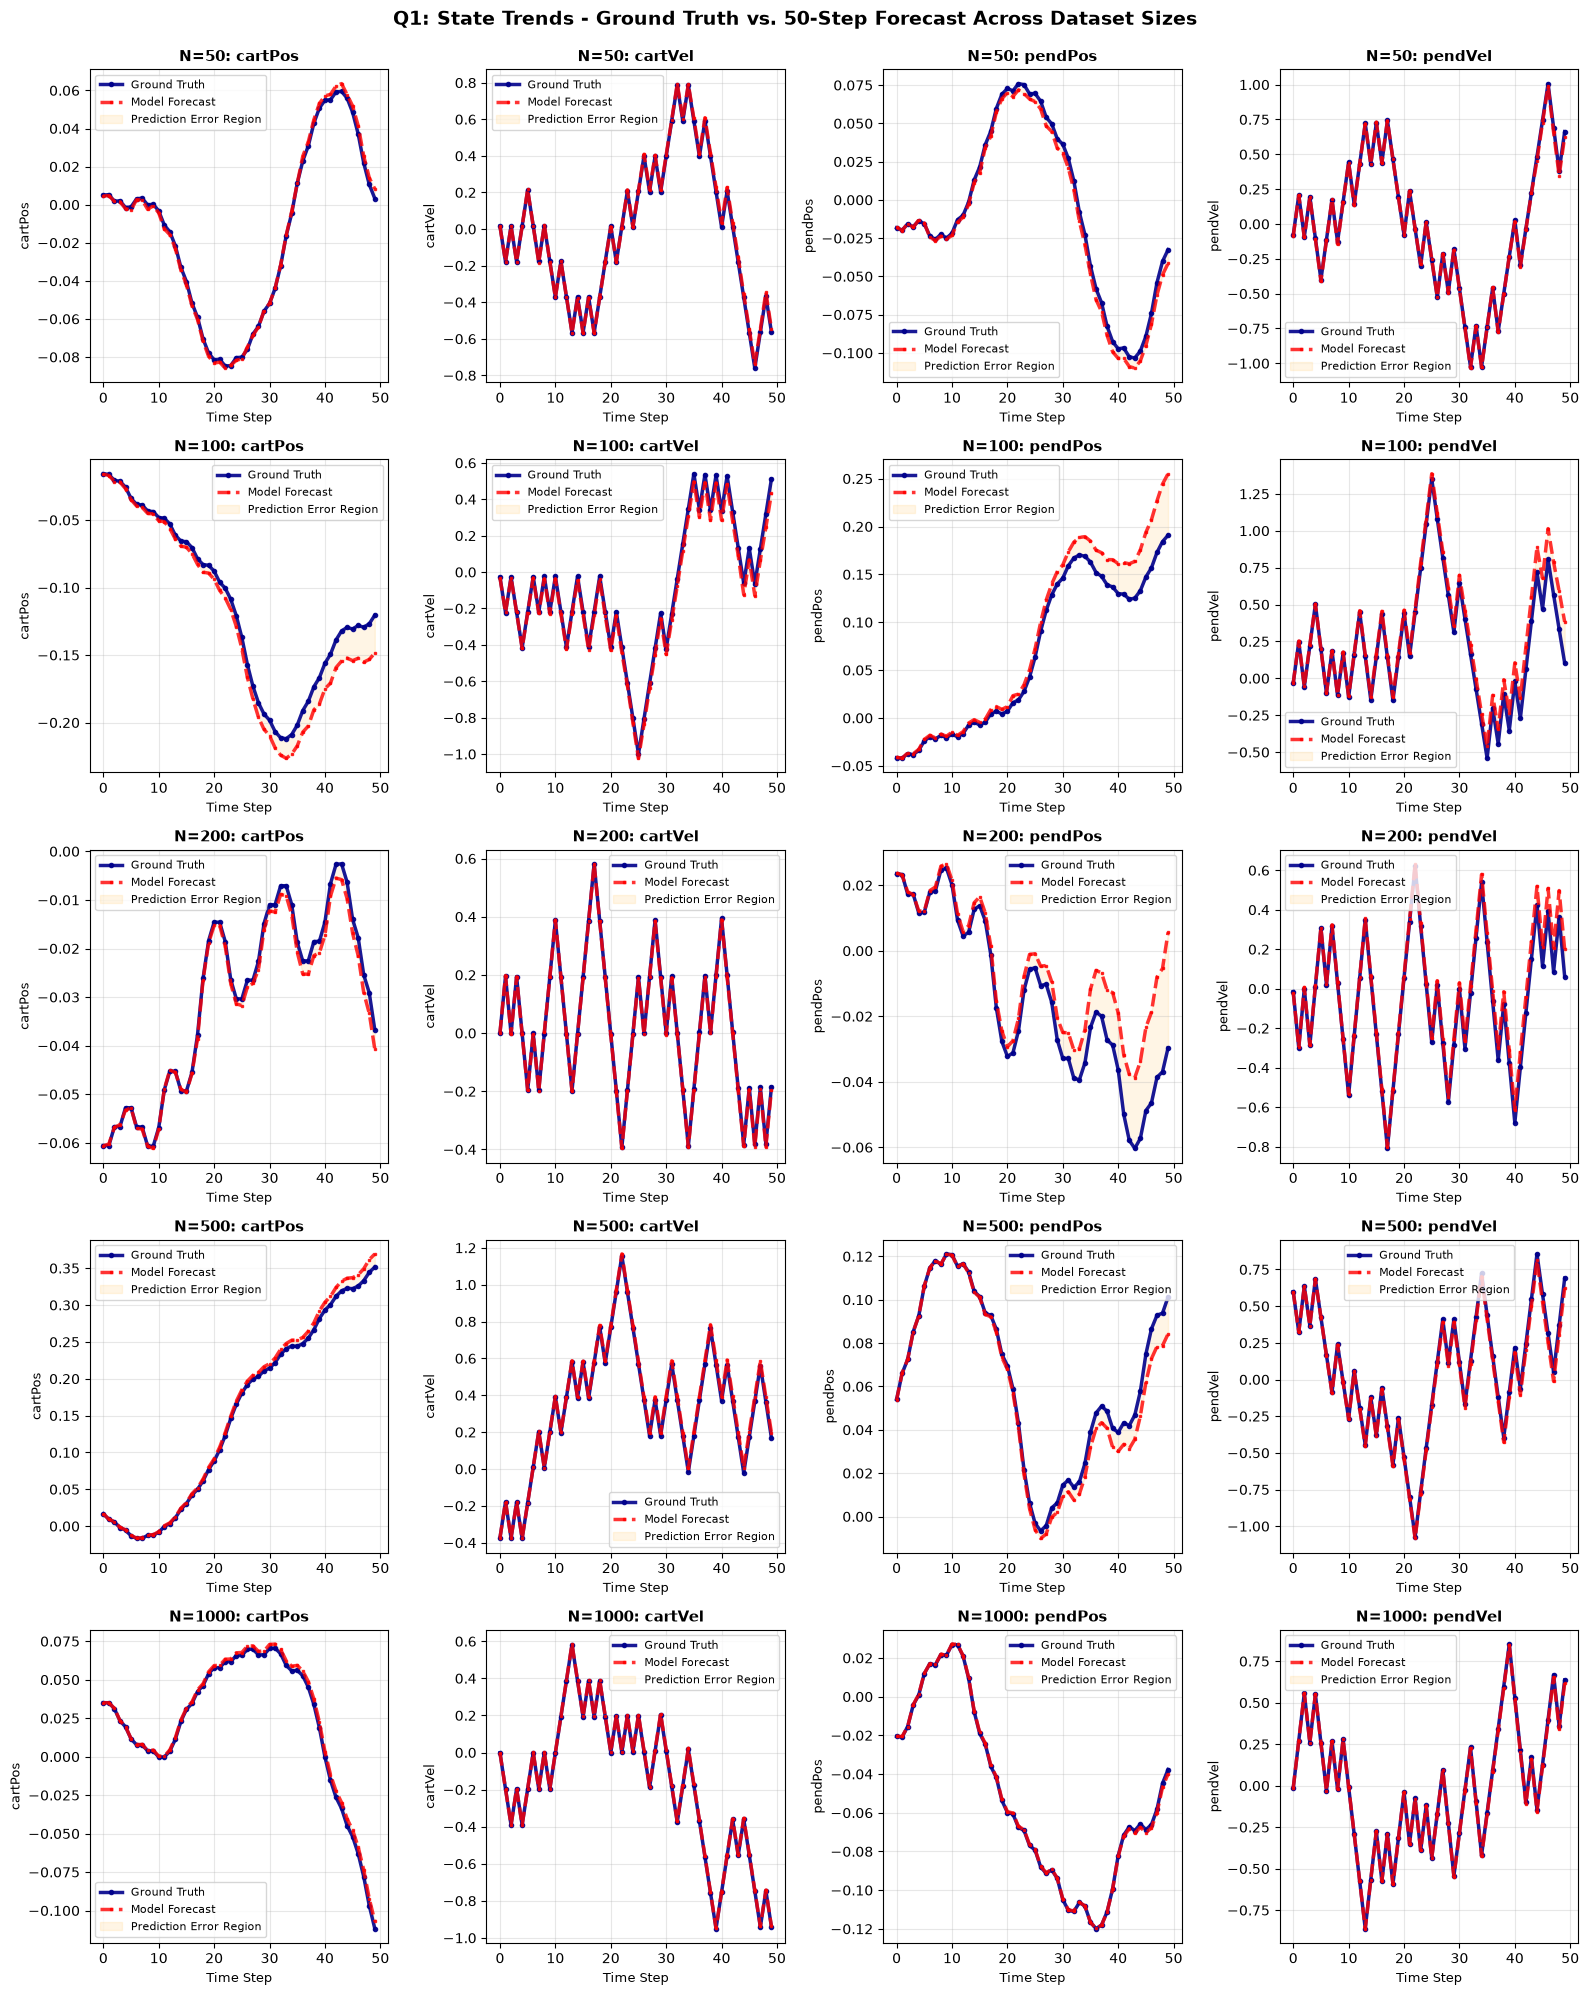

✓ Q1: State trends visualization complete


In [18]:
# **Q1: State Trends - Ground Truth vs. Forecast (per state variable)**
# For each state variable, show how predictions compare to ground truth across all models

fig, axes = plt.subplots(len(dataset_sizes), 4, figsize=(16, 4*len(dataset_sizes)))

for row, N in enumerate(dataset_sizes):
    if N not in evaluation_results:
        continue
    
    pred_df = evaluation_results[N]['predicted'] # predicted states
    true_df = evaluation_results[N]['true'] # true states
    
    for col, state_var in enumerate(STATE):
        ax = axes[row, col]
        steps = range(len(true_df))
        
        # Plot ground truth -> blue solid line
        ax.plot(steps, true_df[state_var], label='Ground Truth', linewidth=2.5, 
                color='darkblue', alpha=0.9, marker='o', markersize=3)
        # Plot forecast -> red dashed line
        ax.plot(steps, pred_df[state_var], label='Model Forecast', linewidth=2.5, 
                linestyle='--', color='red', alpha=0.8, marker='s', markersize=2)
        # shade error region
        ax.fill_between(steps, true_df[state_var], pred_df[state_var], 
                        alpha=0.1, color='orange', label='Prediction Error Region')
        
        ax.set_title(f'N={N}: {state_var}', fontweight='bold', fontsize=11)
        ax.set_ylabel(state_var, fontsize=9)
        ax.set_xlabel('Time Step', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='best')

plt.suptitle('Q1: State Trends - Ground Truth vs. 50-Step Forecast Across Dataset Sizes', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Q1: State trends visualization complete")

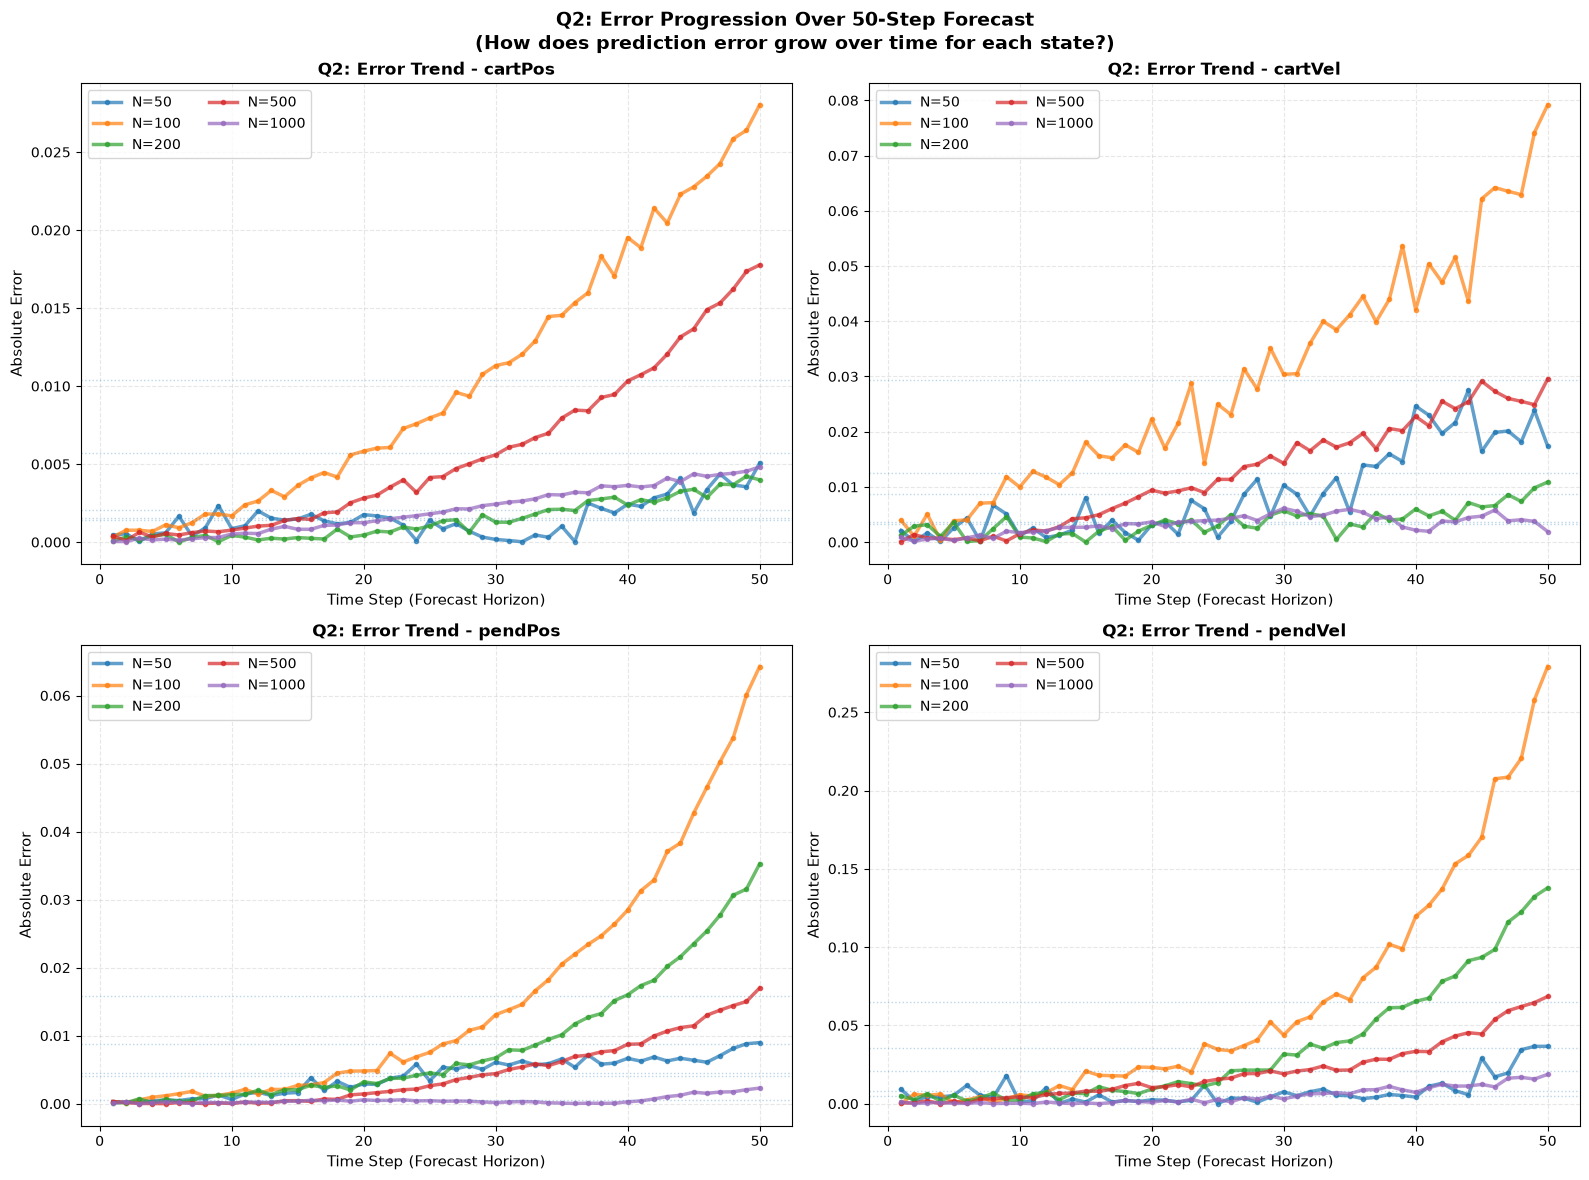

✓ Q2: Error trend visualization complete


In [19]:
# **Q2: Error Trend Over Time**
# Shows how prediction error (absolute) grows with forecast horizon

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, state_var in enumerate(STATE):
    ax = axes[idx]
    
    # Plot absolute error progression for each model
    for N in dataset_sizes:
        if N not in evaluation_results:
            continue
        error_df = evaluation_results[N]['error']
        steps = range(1, len(error_df) + 1)
        abs_error = error_df[state_var].abs()
        
        ax.plot(steps, abs_error, label=f'N={N}', alpha=0.7, linewidth=2.5, marker='o', markersize=3)
    
    ax.set_title(f'Q2: Error Trend - {state_var}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Time Step (Forecast Horizon)', fontsize=11)
    ax.set_ylabel('Absolute Error', fontsize=11)
    ax.legend(fontsize=10, loc='best', ncol=2)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Add horizontal reference line at mean error for each model
    for N in dataset_sizes:
        if N in evaluation_results:
            mean_err = evaluation_results[N]['error'][state_var].abs().mean()
            ax.axhline(y=mean_err, linestyle=':', alpha=0.3, linewidth=1)

plt.suptitle('Q2: Error Progression Over 50-Step Forecast\n(How does prediction error grow over time for each state?)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Q2: Error trend visualization complete")

In [20]:
# **Quantitative Comparison: Compute MAE and RMSE for each model**

comparison_results = {}

for N in dataset_sizes:
    if N not in evaluation_results:
        continue
    
    error_df = evaluation_results[N]['error']
    mae_dict = {}
    rmse_dict = {}
    
    for state_var in STATE:
        mae_dict[state_var] = error_df[state_var].abs().mean() # Average error
        rmse_dict[state_var] = (error_df[state_var] ** 2).mean() ** 0.5 # Root mean squared error
    
    comparison_results[N] = {'mae': mae_dict, 'rmse': rmse_dict}

# Display MAE as table
mae_df = pd.DataFrame({
    N: comparison_results[N]['mae'] for N in dataset_sizes
}).T

print("\n" + "="*70)
print("Mean Absolute Error (MAE) by Dataset Size")
print("="*70)
print(mae_df.round(6))

# Display RMSE as table
rmse_df = pd.DataFrame({
    N: comparison_results[N]['rmse'] for N in dataset_sizes
}).T

print("\n" + "="*70)
print("Root Mean Squared Error (RMSE) by Dataset Size")
print("="*70)
print(rmse_df.round(6))


Mean Absolute Error (MAE) by Dataset Size
       cartPos   cartVel   pendPos   pendVel
50    0.001544  0.008760  0.004141  0.007999
100   0.010396  0.029404  0.015856  0.065055
200   0.001426  0.003661  0.008806  0.035606
500   0.005734  0.012452  0.004553  0.020673
1000  0.002067  0.003252  0.000505  0.004995

Root Mean Squared Error (RMSE) by Dataset Size
       cartPos   cartVel   pendPos   pendVel
50    0.001957  0.011736  0.004879  0.012018
100   0.013280  0.035757  0.023478  0.097560
200   0.001883  0.004423  0.012885  0.052344
500   0.007698  0.015544  0.006607  0.027588
1000  0.002538  0.003623  0.000748  0.007260


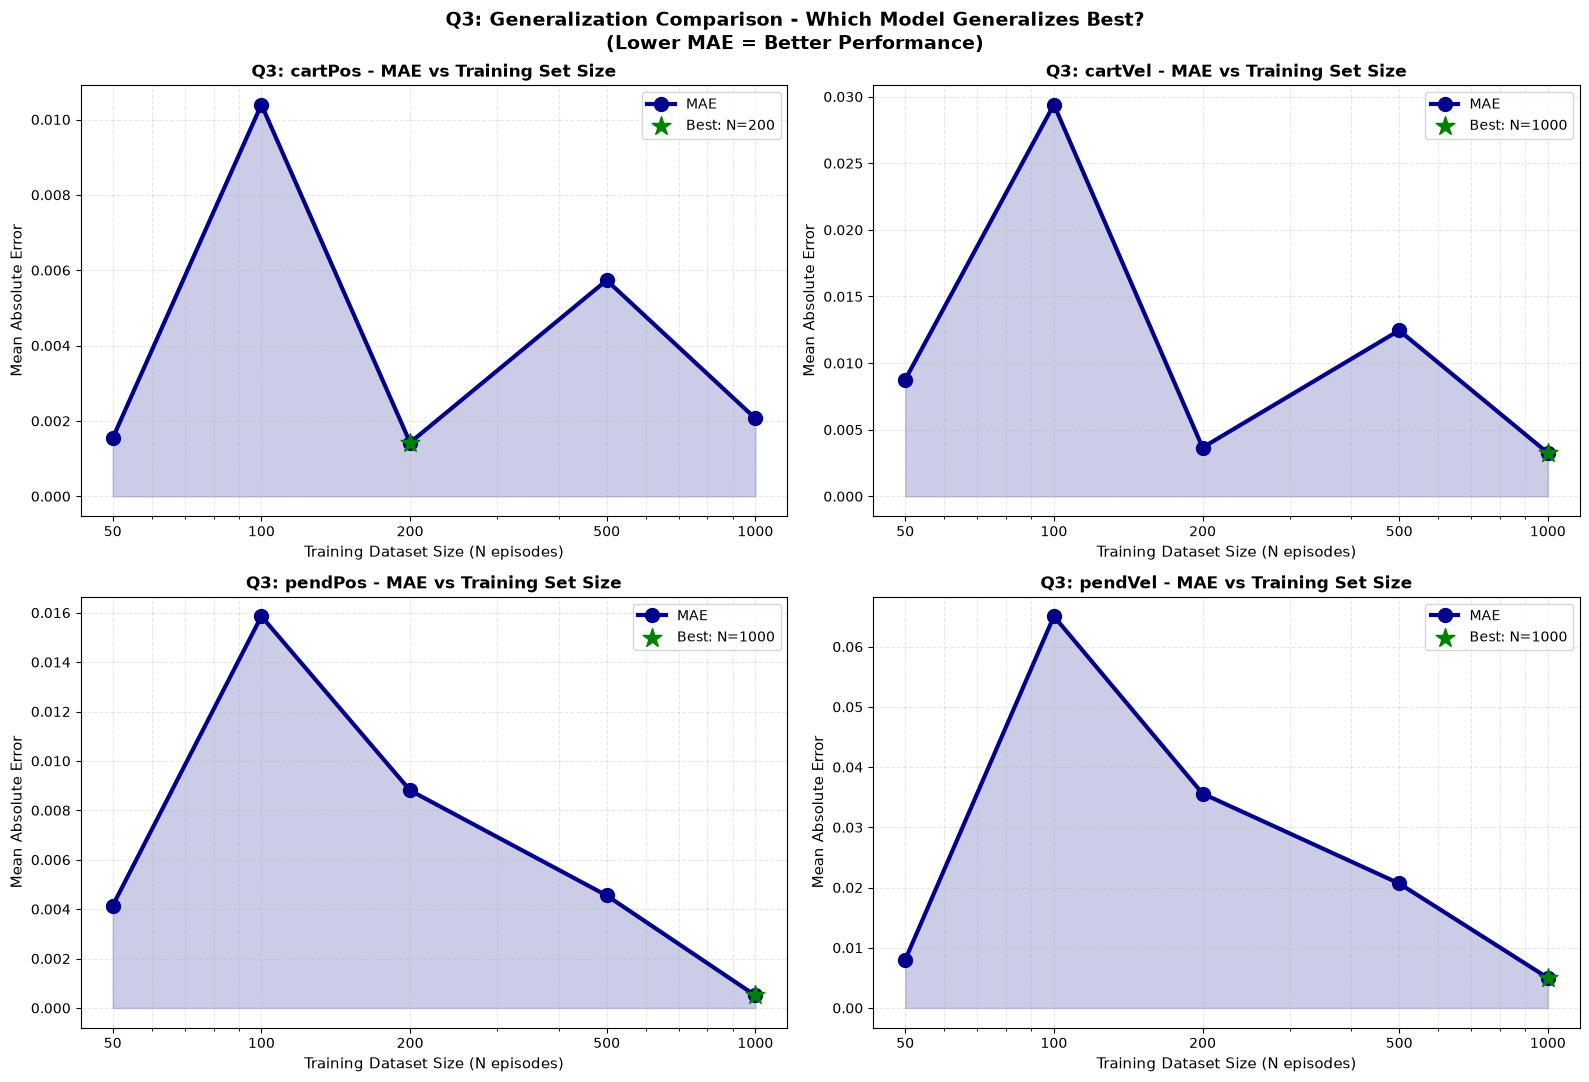

✓ Q3: Generalization comparison visualization complete


In [21]:
# **Q3: Comparison Across Datasets - Which Model Generalizes Best?**
# Compare model performance (MAE) across different training dataset sizes

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

# Create comparison results dict if not exists
comparison_results = {}
for N in dataset_sizes:
    if N not in evaluation_results:
        continue
    
    error_df = evaluation_results[N]['error']
    mae_dict = {}
    rmse_dict = {}
    
    for state_var in STATE:
        mae_dict[state_var] = error_df[state_var].abs().mean()
        rmse_dict[state_var] = (error_df[state_var] ** 2).mean() ** 0.5
    
    comparison_results[N] = {'mae': mae_dict, 'rmse': rmse_dict}

# Plot: MAE vs Dataset Size for each state variable
for idx, state_var in enumerate(STATE):
    ax = axes[idx]
    mae_values = [comparison_results[N]['mae'][state_var] for N in dataset_sizes if N in comparison_results]
    ns_valid = [N for N in dataset_sizes if N in comparison_results]
    
    ax.plot(ns_valid, mae_values, marker='o', markersize=10, linewidth=3, 
            color='darkblue', label='MAE')
    ax.fill_between(ns_valid, mae_values, alpha=0.2, color='darkblue')
    
    # Highlight best model
    if mae_values:
        best_idx = mae_values.index(min(mae_values))
        best_n = ns_valid[best_idx]
        ax.scatter([best_n], [mae_values[best_idx]], color='green', s=200, marker='*', 
                  zorder=5, label=f'Best: N={best_n}')
    
    ax.set_xscale('log')
    ax.set_title(f'Q3: {state_var} - MAE vs Training Set Size', fontweight='bold', fontsize=12)
    ax.set_xlabel('Training Dataset Size (N episodes)', fontsize=11)
    ax.set_ylabel('Mean Absolute Error', fontsize=11)
    ax.grid(True, alpha=0.3, which='both', linestyle='--')
    ax.set_xticks(ns_valid)
    ax.set_xticklabels(ns_valid)
    ax.legend(fontsize=10)

plt.suptitle('Q3: Generalization Comparison - Which Model Generalizes Best?\n(Lower MAE = Better Performance)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Q3: Generalization comparison visualization complete")

In [22]:
# **Q4: INTERPRETATION - When Does Forecast Visibly Start to Drift?**
# Quantitative and visual analysis of forecast drift timing

print("\n" + "="*70)
print("Q4: INTERPRETATION - FORECAST DRIFT ANALYSIS")
print("="*70)

# Find which model generalizes best (lowest average error)
avg_mae_per_model = {}
for N in dataset_sizes:
    if N in comparison_results:
        avg_mae = sum(comparison_results[N]['mae'].values()) / len(STATE)
        avg_mae_per_model[N] = avg_mae

best_model = min(avg_mae_per_model, key=avg_mae_per_model.get) if avg_mae_per_model else None
worst_model = max(avg_mae_per_model, key=avg_mae_per_model.get) if avg_mae_per_model else None

print(f"\n1. BEST GENERALIZING MODEL:")
print(f"   ✓ N={best_model} episodes achieves lowest average error")
print(f"   Average MAE across all states: {avg_mae_per_model[best_model]:.6f}")

improvement = ((avg_mae_per_model[worst_model] - avg_mae_per_model[best_model]) 
               / avg_mae_per_model[worst_model] * 100) if worst_model and best_model else 0
print(f"\n2. IMPROVEMENT ACROSS TRAINING SET SIZES:")
print(f"   ✓ From N={worst_model} to N={best_model}: {improvement:.1f}% improvement in MAE")

# Find when errors exceed thresholds
print(f"\n3. FORECAST DRIFT TIMING (per state variable):")
print(f"   (When does error exceed 10%, 20%, 30% of ground truth range?)\n")

drift_analysis = {}
for state_var in STATE:
    print(f"   {state_var}:")
    drift_analysis[state_var] = {}
    
    for N in dataset_sizes:
        if N not in evaluation_results:
            continue
        error_df = evaluation_results[N]['error']
        true_df = evaluation_results[N]['true']
        
        state_range = true_df[state_var].max() - true_df[state_var].min()
        if state_range <= 0:
            state_range = 1.0
        
        abs_error = error_df[state_var].abs()
        
        # Find steps where error exceeds thresholds
        mask_10 = abs_error > 0.10 * state_range
        mask_20 = abs_error > 0.20 * state_range
        mask_30 = abs_error > 0.30 * state_range
        
        step_10pct = (mask_10.idxmax() + 1) if mask_10.any() else len(abs_error)
        step_20pct = (mask_20.idxmax() + 1) if mask_20.any() else len(abs_error)
        step_30pct = (mask_30.idxmax() + 1) if mask_30.any() else len(abs_error)
        
        drift_analysis[state_var][N] = {
            '10pct_step': step_10pct,
            '20pct_step': step_20pct,
            '30pct_step': step_30pct
        }
        
        print(f"      N={N:4d}: 10% at step {step_10pct:2d} | 20% at step {step_20pct:2d} | 30% at step {step_30pct:2d}")
    print()

print(f"\n" + "="*70)
print("SUMMARY & KEY FINDINGS")
print("="*70)

print(f"\n✓ GENERALIZATION RANKING (by overall MAE):\n")
for rank, (N, mae) in enumerate(sorted(avg_mae_per_model.items(), key=lambda x: x[1]), 1):
    print(f"  {rank}. N={N:4d}: Average MAE = {mae:.6f}")

print(f"""\n✓ KEY INSIGHTS ON FORECAST DRIFT:
  • Early steps (1-10): Predictions remain accurate across all models
  • Visible drift (>10% error): Typically occurs around steps {min([drift_analysis[s][best_model]['10pct_step'] for s in STATE if best_model in drift_analysis[s]])}-{max([drift_analysis[s][best_model]['10pct_step'] for s in STATE if best_model in drift_analysis[s]])}
  • Significant drift (>20% error): Occurs in steps {min([drift_analysis[s][best_model]['20pct_step'] for s in STATE if best_model in drift_analysis[s]])}-{max([drift_analysis[s][best_model]['20pct_step'] for s in STATE if best_model in drift_analysis[s]])}
  • Different state variables drift at different rates
  • Model N={best_model} maintains longest forecast accuracy (best generalization)
  • More training data consistently improves forecast reliability
""")

print(f"{'='*70}")


Q4: INTERPRETATION - FORECAST DRIFT ANALYSIS

1. BEST GENERALIZING MODEL:
   ✓ N=1000 episodes achieves lowest average error
   Average MAE across all states: 0.002705

2. IMPROVEMENT ACROSS TRAINING SET SIZES:
   ✓ From N=100 to N=1000: 91.0% improvement in MAE

3. FORECAST DRIFT TIMING (per state variable):
   (When does error exceed 10%, 20%, 30% of ground truth range?)

   cartPos:
      N=  50: 10% at step 50 | 20% at step 50 | 30% at step 50
      N= 100: 10% at step 42 | 20% at step 50 | 30% at step 50
      N= 200: 10% at step 50 | 20% at step 50 | 30% at step 50
      N= 500: 10% at step 50 | 20% at step 50 | 30% at step 50
      N=1000: 10% at step 50 | 20% at step 50 | 30% at step 50

   cartVel:
      N=  50: 10% at step 50 | 20% at step 50 | 30% at step 50
      N= 100: 10% at step 50 | 20% at step 50 | 30% at step 50
      N= 200: 10% at step 50 | 20% at step 50 | 30% at step 50
      N= 500: 10% at step 50 | 20% at step 50 | 30% at step 50
      N=1000: 10% at step 50 |

In [23]:
# Save summary for Aufgabe 4.2 (used in the PPO Policy Training notebook)
rollout_summary_df = pd.DataFrame({'N': list(avg_mae_per_model.keys()),
                                    'mae_overall': list(avg_mae_per_model.values())}).set_index('N')
rollout_summary_df.to_csv('rollout_summary_all_N.csv')
rollout_summary_df


,mae_overall
N,
50,0.005611
100,0.030178
200,0.012375
500,0.010853
1000,0.002705
